<a href="https://colab.research.google.com/github/PankajJoshi0202/demo/blob/master/placementPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv("placedata v2.0 synthetic.csv")

In [ ]:
data.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [ ]:
data.shape

(10000, 12)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [ ]:
data.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()


categorical_cols = ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']

for categories in categorical_cols:
  data[categories]=le.fit_transform(data[categories])

data.drop(["StudentID"],axis=1,inplace=True)

print(data.head())

   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0   7.5            1         1                         1                 65   
1   8.9            0         3                         2                 90   
2   7.3            1         2                         2                 82   
3   7.5            1         1                         2                 85   
4   8.3            1         2                         2                 86   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0               4.4                          0                  0         61   
1               4.0                          1                  1         78   
2               4.8                          1                  0         79   
3               4.4                          1                  1         81   
4               4.5                          1                  1         74   

   HSC_Marks  PlacementStatus  
0         79

In [ ]:
data.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,0.585400,0.731800,69.159400,74.501500,0.419700
std,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,0.492677,0.443044,10.430459,8.919527,0.493534
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,0.000000,0.000000,55.000000,57.000000,0.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,0.000000,0.000000,59.000000,67.000000,0.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,1.000000,1.000000,70.000000,73.000000,0.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,1.000000,1.000000,78.000000,83.000000,1.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,1.000000,1.000000,90.000000,88.000000,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


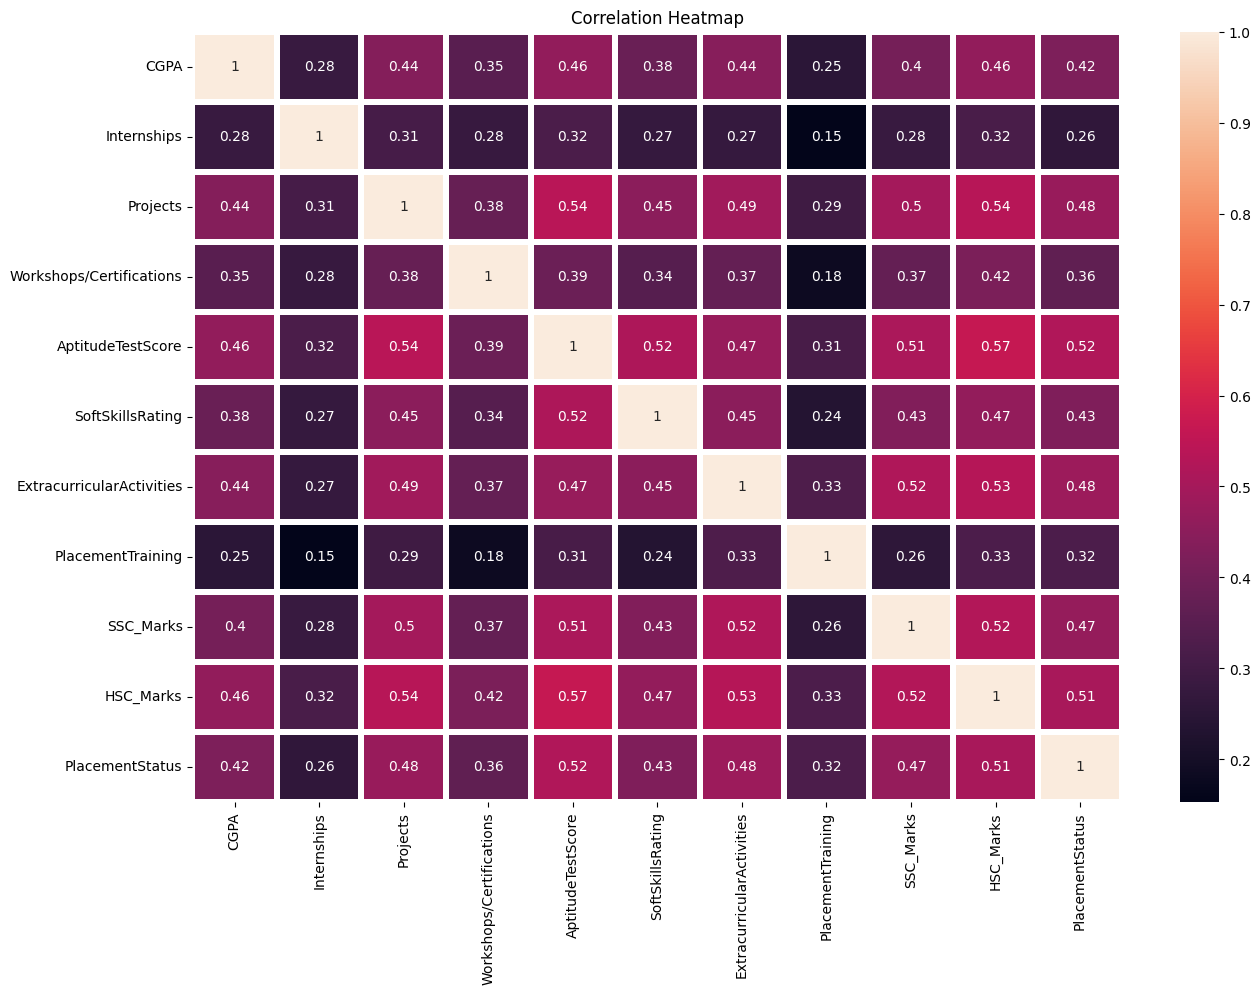

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),linewidths=3,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Internships_effect = data.pivot_table(index = 'PlacementStatus',values="CGPA", columns='Internships', aggfunc='count')
Internships_effect


Internships,0,1,2
PlacementStatus,,,
0,1320,3733,750
1,663,1809,1725


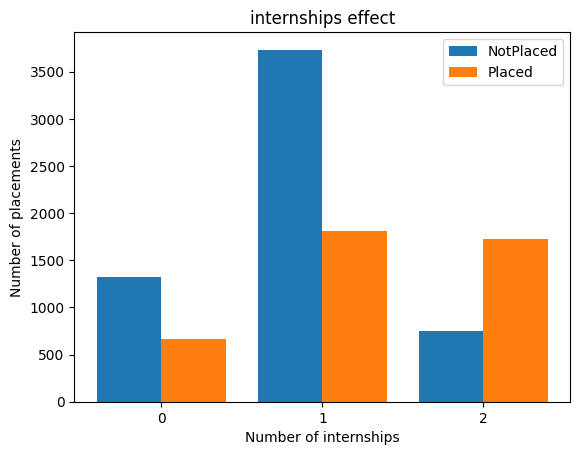

In [ ]:
X = Internships_effect.columns
X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, Internships_effect.iloc[0,:], 0.4, label = 'NotPlaced')
plt.bar(X_axis + 0.2, Internships_effect.iloc[1,:], 0.4, label = 'Placed')

plt.xticks(X_axis, X)
plt.xlabel("Number of internships")
plt.ylabel("Number of placements")
plt.title("internships effect")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.svm import SVC

In [ ]:
y = data['PlacementStatus']

X = data.drop(columns=['PlacementStatus'])


print(X.shape)
print(y.shape)


(10000, 10)
(10000,)


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

Support vector
77.9


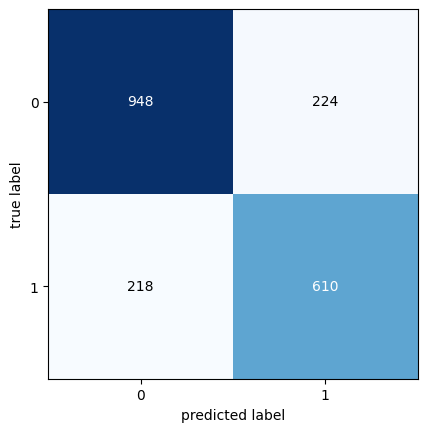



Logistic regression
79.10000000000001


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


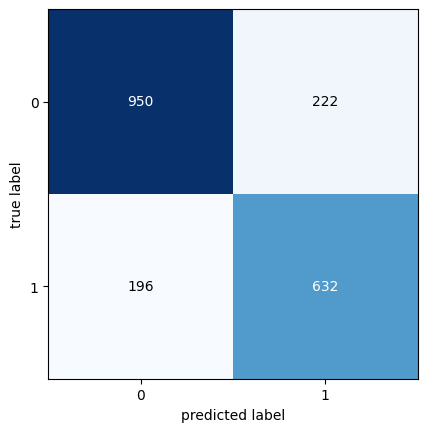



Random Forest
77.60000000000001


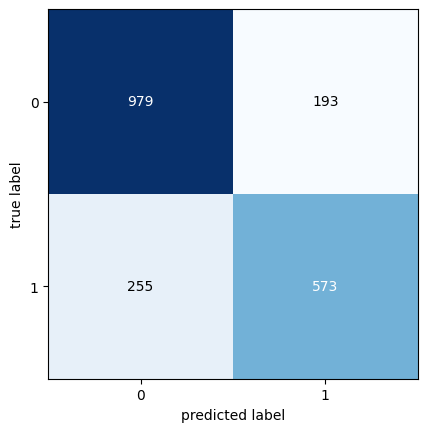



Decision Trees
77.25


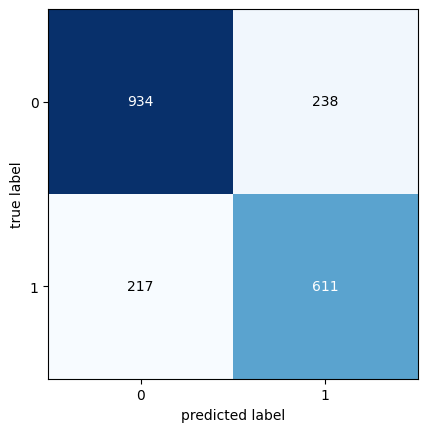



KNeighbourClassifier
77.05


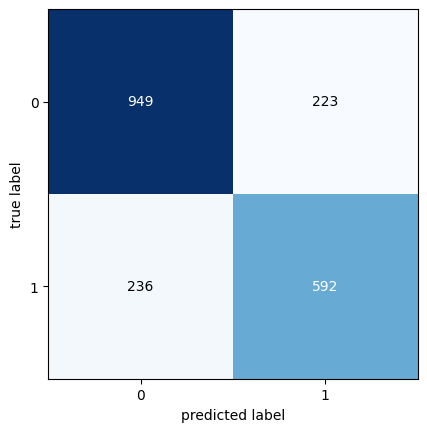



XGBoost
78.14999999999999


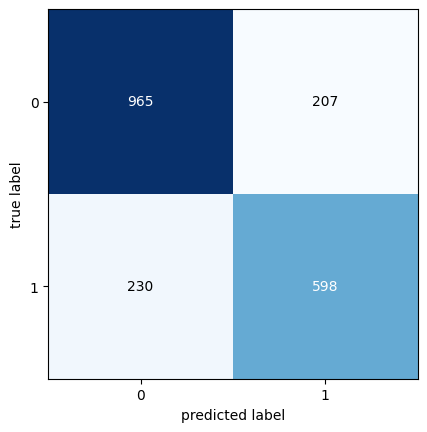



Adaboost
79.0


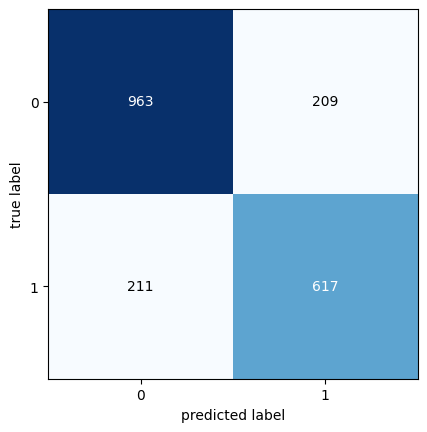



Gradient Boosting
77.55


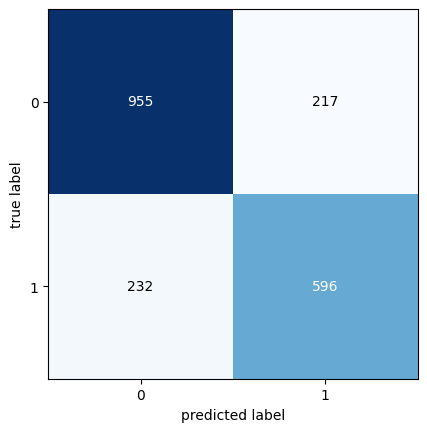

In [ ]:
models = [[SVC(), "Support vector"],
        [LogisticRegression(C=10), "Logistic regression"],
         [RandomForestClassifier(n_estimators = 20), "Random Forest"],
         [DecisionTreeClassifier(max_depth = 7), "Decision Trees"],
         [KNeighborsClassifier(n_neighbors = 7), "KNeighbourClassifier"],
         [xgb.XGBClassifier(objective="binary:logistic", random_state=42), "XGBoost"],
         [AdaBoostClassifier(n_estimators = 25), "Adaboost"],
         [GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=10, random_state=0), "Gradient Boosting"]]

for i in models:
    name = i[1]
    model = i[0]
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test, y_pred) * 100)
    cnf = confusion_matrix(y_test,y_pred)
    fig, ax = plot_confusion_matrix(conf_mat = cnf)
    plt.show()
    print("\n")


In [ ]:
import pickle
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Define AdaBoost model and hyperparameters for tuning
model = AdaBoostClassifier()
grid = {
    'n_estimators': [85, 89, 90, 91, 95],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# Cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Perform Grid Search
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy')
grid_result = grid_search.fit(X_train, y_train)

# Save the best-trained model
best_model = grid_result.best_estimator_
with open('adaboost_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

print(f"✅ Best Model saved as 'adaboost_model.pkl' with parameters: {grid_result.best_params_}")


✅ Best Model saved as 'adaboost_model.pkl' with parameters: {'learning_rate': 0.1, 'n_estimators': 95}


In [ ]:
# Load the model
with open('adaboost_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# Use the loaded model for predictions
y_pred = loaded_model.predict(X_test)

# Evaluate Accuracy
from sklearn.metrics import accuracy_score
print(f"Accuracy of loaded model: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Accuracy of loaded model: 79.05%


In [ ]:
! pip install streamlit -q
!pip install pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load the trained AdaBoost model once
@st.cache_resource
def load_model():
    return joblib.load("adaboost_model.pkl")

model = load_model()

# Title and intro
st.title("🎓 Placement Prediction App")
st.write("Fill in the details below to predict if a student will be placed or not.")

# Form for user input
with st.form("placement_form"):
    col1, col2 = st.columns(2)

    with col1:
        CGPA = st.number_input("CGPA (0-10)", 0.0, 10.0, step=0.01)
        Internships = st.number_input("Internships", 0, 10)
        Projects = st.number_input("Projects", 0, 10)
        Workshops = st.number_input("Workshops/Certifications", 0, 10)
        AptitudeTestScore = st.number_input("Aptitude Score (0-100)", 0, 100)

    with col2:
        SoftSkillsRating = st.number_input("Soft Skills (0-10)", 0.0, 10.0, step=0.1)
        SSC_Marks = st.number_input("SSC Marks (%)", 0, 100)
        HSC_Marks = st.number_input("HSC Marks (%)", 0, 100)
        Extracurricular = st.selectbox("Extracurricular Activities", ["No", "Yes"])
        PlacementTraining = st.selectbox("Placement Training", ["No", "Yes"])

    # Submit button
    submit = st.form_submit_button("Predict Placement Status")

# Prediction logic
if submit:
    # Convert categorical inputs
    Extracurricular = 1 if Extracurricular == "Yes" else 0
    PlacementTraining = 1 if PlacementTraining == "Yes" else 0

    # Input array
    input_data = np.array([[CGPA, Internships, Projects, Workshops, AptitudeTestScore,
                            SoftSkillsRating, Extracurricular, PlacementTraining,
                            SSC_Marks, HSC_Marks]])

    # Model prediction
    prediction = model.predict(input_data)[0]
    result = "🎉 Placed" if prediction == 1 else "❌ Not Placed"

    st.success(f"Prediction: **{result}**")

# Footer
st.markdown("---")


Writing app.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.73.39.46


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.39.46:8501

⠼⠴⠦your url is: https://cold-rings-invite.loca.lt
